# Lesson 173 · Multi-task pre-training

**One skill:** design and implement the loss for a masked-cell training loop. The next narrative contains **saved author-reference evidence**, not results from your kernel. The executable section below runs a fresh full seed-0 fit. Tier B: real F1 database, course-defined autocomplete targets. Whole-paper reproduction NOT_RUN.

**One win:** turn typed cells into a training objective, then explain why changing the averaging rule changes what the model learns. About 20 minutes for the lesson; run the lab separately.

[Lesson 171: choose the corpus](https://avistian.github.io/relational/lessons/0171-corpus-of-databases.html) → [Lesson 172: encode its cells](https://avistian.github.io/relational/lessons/0172-schema-tokenization.html) → **173: decide what gets learned** → Lesson 174: adapt the resulting encoder.

## 1 · A masked token is not yet a training example

Lesson 172 gave each cell a type, state and payload. It deliberately stopped before learning. Now separate three objects: **input context** contains permitted visible cells; **target** holds the hidden answer outside the model input; **loss** measures a prediction against that answer. A MASKED state alone does not prevent a join or a second reference from revealing the same target.

We build an **autocomplete** task for each eligible column, such as `results.points` or `results.statusId`. For every observed target cell, remove its identity from all context slots. Predict its value from up to four other eligible same-row cells and four eligible FK-parent cells. A numerical target is its normalized value; a categorical target is its local vocabulary class. Each eligible target appears once per epoch: we do not take a random 15% mask sample.

**This is autocomplete, not forecasting.** Other same-row fields may describe the same completed race and may almost determine the answer. Good reconstruction does not establish advance prediction. The packet also contains only one database; this is multi-task training, not evidence of a transferable foundation model.

## 2 · Four axes describe access to information

[KumoRFM-2, §3](https://arxiv.org/html/2604.12596v1#S3) discusses row, column, foreign-key and cross-sample processing. These are not four scalar losses you can simply add. A model can access several kinds of context while optimizing one target loss.

| Information axis | Question it helps answer | This course model |
|---|---|---|
| Row | What do other fields say about this record? | Up to four other cells |
| Column | What patterns recur down this field? | No column-attention mechanism |
| Foreign key | What do linked records say? | Up to four dated parent cells |
| Cross-sample | What do labeled examples reveal about this task? | No ICL support mechanism |

The FK slots retain links through the schema, never use key IDs as magnitudes, and exclude untimed or future parent rows. Both row and FK slots are capped in a declared sorted order. That cheap deterministic policy can discard useful features; it is a course choice, not a learned selection algorithm.

## 3 · Model architecture: one encoder, many heads

**Recall the building blocks.** An embedding is a learned vector of numbers representing a column or category. A numerical projection multiplies a scalar value by learned weights to produce a vector. Pooling takes an average of visible vectors. A multilayer perceptron (MLP) applies learned linear transformations with nonlinear activations between them. A head is the final task-specific prediction layer; logits are its unnormalized class scores. Here B means the number of target cells processed together, and K is the number of classes for one categorical task.

**Read the diagram left to right before reading the code.** A token combines a column embedding with either a numerical projection or a categorical embedding. The model averages visible row and parent tokens separately. It combines both averages with the target column's embedding, then sends the shared representation to that column's head.

<figure tabindex="0" style="overflow-x:auto">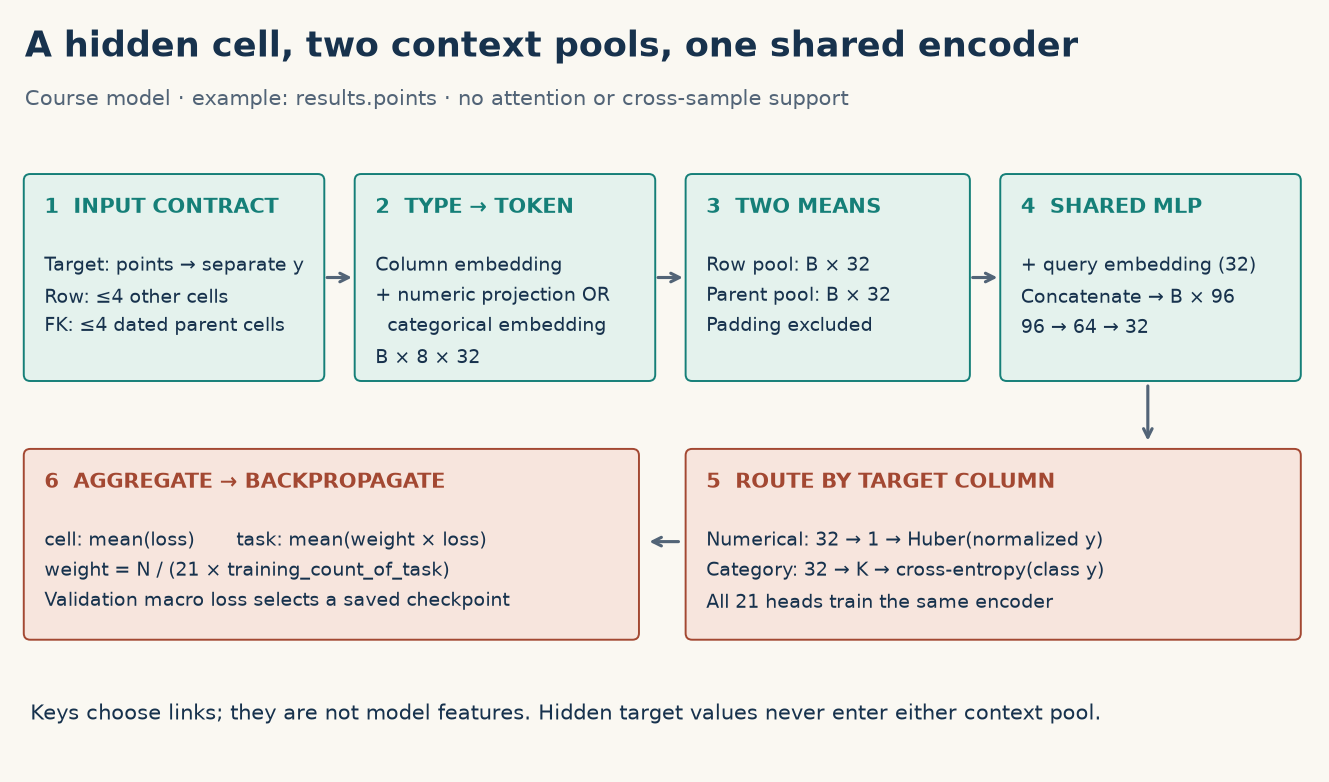<figcaption>Course model computation: erase the target; embed visible row and dated FK-parent cells; pool separately; share the encoder; route a local head; aggregate scalar losses. Shapes use batch B. Scroll horizontally on narrow screens.</figcaption></figure>

For a batch of B target cells, context IDs have shape **B × 8**. Encoded tokens are **B × 8 × 32**. Two 32-wide means plus a 32-wide query make **B × 96**; the shared MLP maps 96 → 64 → 32. A numerical head returns one value. A categorical head returns K logits, one per local class including UNKNOWN. Padding contributes neither to the sum nor its denominator. An empty context pool is a zero vector.

The implementation is visible in the notebook: `MaskedCellModel.forward` builds tokens, pools two contexts and routes heads; `cell_losses` applies the appropriate criterion; `train_run` updates shared weights. Column embeddings and heads are local to these 21 tasks. Nothing here establishes cross-schema meaning.

[Relational Transformer v1, §3.3](https://arxiv.org/html/2510.06377v1#S3.SS3) provides the primary objective reading: numerical Huber loss, boolean BCE, and a mean across masked cells. Our **multiclass cross-entropy**, pooled MLP, local column heads and equal-task comparison are declared course deviations. We do not implement RT attention or its pretraining schedule.

## 4 · A mean hides a policy decision

> **In plain terms.** Averaging every cell gives frequently observed columns more influence. Averaging each column's loss first gives each task one vote. Choose the question you want the training objective to answer before choosing the average.

For numerical residual e, Huber with threshold 1 is `0.5 × e²` when `|e| ≤ 1`, otherwise `|e| − 0.5`. This operates on the training-normalized target. Categorical cross-entropy is `logsumexp(logits) − logit_of_correct_class`. The losses have different interpretations even though both return scalars.

Let task t contain Nₜ training targets and have mean loss Lₜ. A **cell mean** is `Σ Nₜ Lₜ / Σ Nₜ`: large tasks receive more weight. An **equal-task mean** is `Σ Lₜ / T`: each task receives one vote. Neither is automatically right; both still depend on target normalization and task definitions.

Predict before computing: do nine errors of 1 and one error of 5 give the same cell and task mean?

**Worked example:** task A has nine cells with mean loss 1; task B has one cell with loss 5. Cell weighting gives `(9 × 1 + 1 × 5) / 10 = 1.4`. Equal-task weighting gives `(1 + 5) / 2 = 3`. The model has not changed; your definition of improvement has.

<figure tabindex="0" style="overflow-x:auto">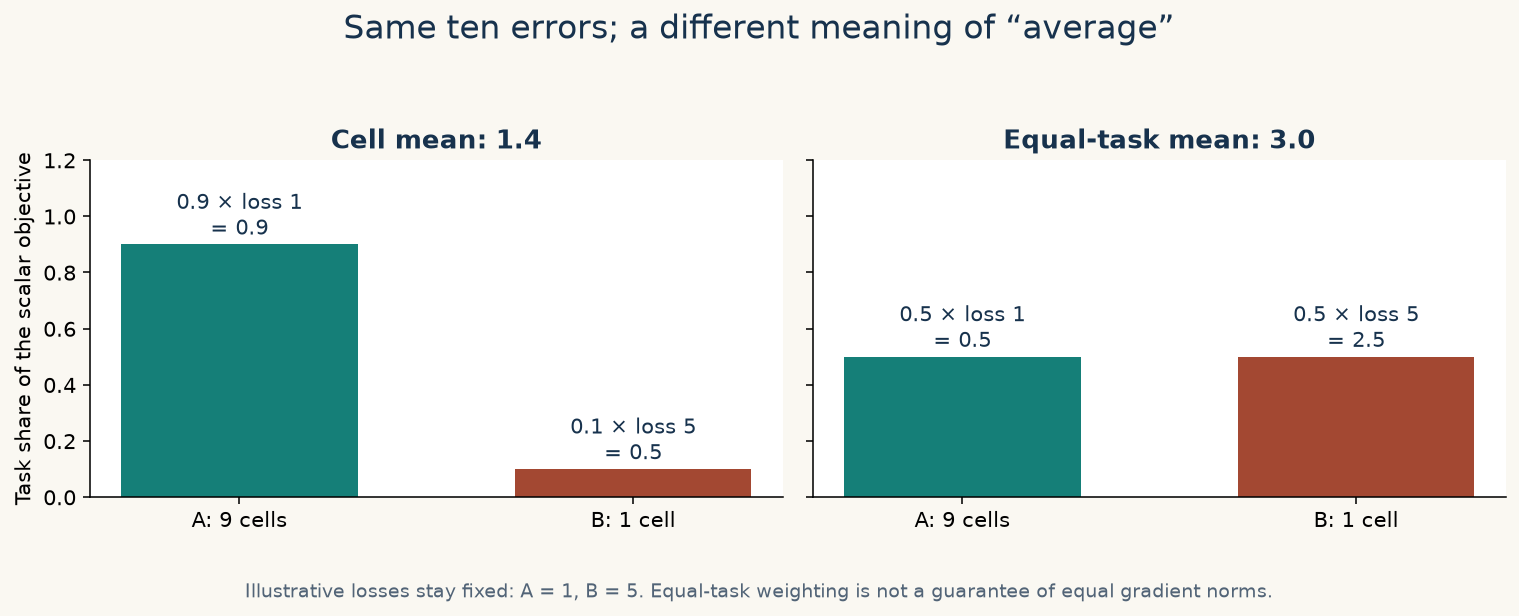<figcaption>Illustrative fixed errors: nine A cells at loss 1, one B cell at loss 5. Changing weights changes 1.4 to 3 without changing predictions. Scroll horizontally on narrow screens.</figcaption></figure>

Intervention: increase A from 9 to 99 cells while keeping both task losses fixed. Cell mean becomes 1.04; equal-task mean stays 3. The CHECK cell below calculates both rules.

For uniformly shuffled training examples, assign each task-t example weight `N / (T × Nₜ)`. Average the weighted losses over the minibatch. The expectation is the equal-task objective. **Use frozen whole-training counts**, not counts of tasks that happen to appear in that minibatch. In the example, an A cell weighs 10/18 and a B cell weighs 5. Their total weights are both 5. This balances scalar objective contributions, not necessarily gradient norms.

**Trace a one-cell minibatch.** Keep nine A cells with loss 1 and one B cell with loss 5. Uniform cell sampling picks A with probability 0.9 and B with probability 0.1. Frozen population weights yield:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Sampled task</th><th>Weight</th><th>Weighted loss</th><th>Expected loss</th></tr></thead><tbody><tr><td>A</td><td>5/9</td><td>5/9</td><td>0.9 × 5/9 = 0.5</td></tr><tr><td>B</td><td>5</td><td>25</td><td>0.1 × 25 = 2.5</td></tr></tbody></table>

The expectation is **3**, even though neither possible one-cell batch loss equals 3. Recomputing weights from each one-cell batch would give weight 1 every time and recover the cell mean **1.4** instead. **Transfer check:** duplicate every A cell, producing counts 18 and 1. Frozen weights become 19/36 and 19/2; the expectation is still 3. Equal-task weighting removes task-frequency influence in expectation, not sampling noise or differences in gradient magnitude.

## 5 · Freeze the comparison before seeing test results

**Named experiment: L173 F1 Multi-task Masked-cell Pretraining.** We reuse the pinned nine-table F1 snapshot and Lesson 172's feature policies. Train before 2005, validate during 2005, and test from 2006 onward. These are course autocomplete splits, not the published RelBench forecasting task splits. Fit normalization and category vocabularies only on training rows. Keys, text, timestamps and every untimed table are excluded from predictive features and targets; the coverage ledger records every exclusion.

An observed held-out category absent from training becomes class 0, **UNKNOWN**. We count it in evaluation. Because no training target has that class, a low accuracy on unseen categories is a real vocabulary limitation, not a reason to refit on test data.

Six fresh fits compare two averaging rules at seeds 0, 1 and 2. Paired arms share initialization, target masks, permutation and batch order. Each fit runs three full epochs, batch size 1,024, Adam at 0.001, no weight decay. Both arms select the earliest checkpoint with lowest **validation macro task loss**. Only then do we score its full test population. All epoch checkpoints remain inspectable.

**Complete:** 370,024 targets across 21 tasks. Train / validation / test: 244,410 / 6,354 / 119,260.

| Loss weighting | Seed 0 test | Seed 1 test | Seed 2 test | Mean ± sample SD |
|---|---:|---:|---:|---:|
| cell | 1.338310 | 1.327036 | 1.341849 | 1.335732 ± 0.007736 |
| task | 1.288805 | 1.304340 | 1.348481 | 1.313875 ± 0.030960 |

All entries are **test macro task loss** (lower is better), even for the cell-weighted training arm. Training-only constant baseline: **1.276529**. Each run scores all 119,260 test targets.

<figure tabindex="0" style="overflow-x:auto">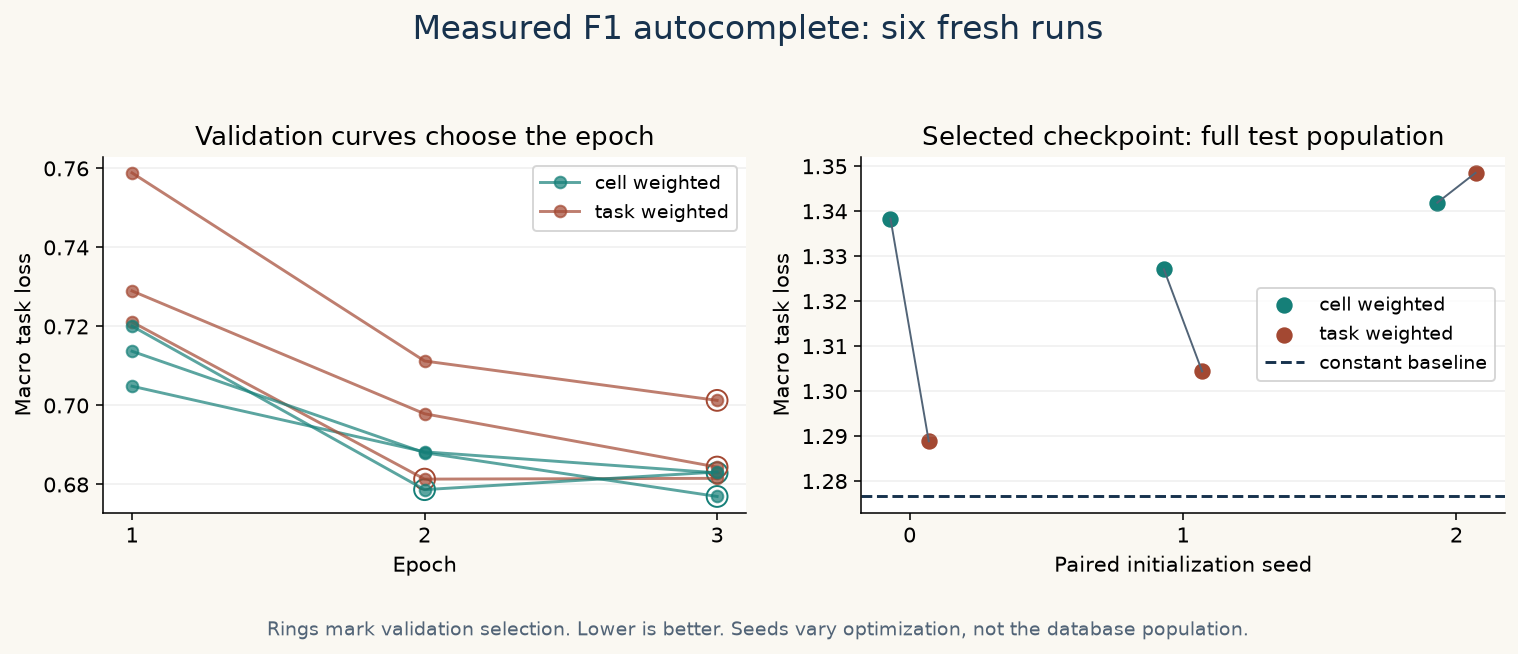<figcaption>Measured six-run evidence. Circles outline the validation-selected epoch; paired seed points show complete test-population macro loss. Test targets are scored after selection. Scroll horizontally on narrow screens.</figcaption></figure>

**Measured interpretation:** equal-task weighting changes test macro loss by -0.021857 on average (task minus cell). The three paired changes are -0.049505, -0.022696, +0.006632. One seed reverses the direction. **Every trained run has higher test macro loss than the constant baseline.** This short pretraining schedule has not established an aggregate predictive benefit, even against that simple comparator. This supports a description of these six runs, not a general claim that equal-task weighting is better. Test losses also exceed validation losses substantially; do not present the validation curve as future-period performance.

[Inspect all 21 per-task validation curves](https://avistian.github.io/relational/labs/figures/l173/per-task-curves.svg). Each panel shows the mean and sample SD across seeds; loss scales differ between tasks.

The baseline predicts the training mean for numerical tasks and Laplace-smoothed training class frequencies for categorical tasks. Report raw-unit MAE for each numerical column and accuracy for each categorical column; do not average those metrics together. The macro loss is a declared scalar criterion, not a common physical unit. Three initialization seeds on one database do not measure uncertainty across databases.

## 6 · Evidence is stronger when you try to break it

The independent verifier reconstructs the complete target population and context slots from the raw tables. It checks key identity, training-only normalization/vocabulary, exact split membership, target removal and nonfuture parent dates. It then changes hidden target payloads and requires unchanged predictions. A separate NumPy calculation scores the saved logits, and selected checkpoints must regenerate exactly the stored predictions. All 18 validation checkpoints are rescored to audit selection.

Temporal order is only as good as the source timestamp. This snapshot lacks historical ingestion histories. Event-time checks do not establish that every recorded value was actually known then. Nor do they prevent same-row proxy fields from making autocomplete easy.

**Reproduction boundary:** this is a complete selected course experiment if all six fits finish. Whole-paper RT/KumoRFM reproduction is **NOT_RUN**; cross-database transfer and historical availability are **NOT_ESTABLISHED**. RT reports about 16 A100 GPU-hours per pretrain in [§4.1](https://arxiv.org/html/2510.06377v1#S4.SS1), exceeding our $10 budget before evaluation. The approved lane uses $0 cloud/API and a 3,600-second aggregate numerical ceiling, including failed attempts. A cutoff is INCOMPLETE, never permission to silently reduce the population.

## 7 · Implement, check, defend

[Student notebook](https://avistian.github.io/relational/labs/0173-multi-task-pretraining.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0173-multi-task-pretraining.html) · [Quick reference](https://avistian.github.io/relational/reference/multi-task-pretraining.html) · [Protocol and exact commands](https://avistian.github.io/relational/labs/l173-reproduction.md) · [Per-task evidence](https://avistian.github.io/relational/labs/evidence/l173/report.md)

Three live learner functions erase targets, assign training-population weights and select a checkpoint from validation scores. Immediate CHECK cells reject common wrong implementations. The notebook provides readable model and training code, authenticated portable inputs, a fresh three-epoch seed-0 cell-weighted run, and a gated six-fit reproduction. Saved author results are labeled separately from your current kernel output.

**EXIT:** explain why balancing tasks can hurt the cell mean; trace one numerical and one categorical loss; give a target-copy counterexample; name the missing architecture pieces for cross-sample ICL; and explain why lower reconstruction loss does not prove transfer. Attach your code, curves and a 200–400-word defense. Author execution leaves learner status **PENDING_WRITTEN_DEFENSE**.

Write your defense before reading any teacher feedback.

Ask the agent about any unclear step. Next, [Lesson 174](https://avistian.github.io/relational/lessons/0174-fine-tuning-protocol.html) tests what adapting a pretrained encoder means; this lesson does not assume that pretraining helps downstream tasks.


In [1]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
import copy,hashlib,json,base64,io,zipfile
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
import pandas as pd
import matplotlib.pyplot as plt
torch.set_num_threads(1)
print("Author runtime: torch 2.13.0+cpu; exact replay may differ on other versions or devices.")

Author runtime: torch 2.13.0+cpu; exact replay may differ on other versions or devices.


## PROVIDED · Portable authenticated population
All 370,024 targets, full raw input packet, training-only metadata and saved author results. No network download or account needed. A hash checks integrity, not historical availability. The provided preparation script and independent verifier in the repository reconstruct the arrays from the raw tables.

In [2]:
encoded='...'
raw=base64.b64decode(encoded)
assert hashlib.sha256(raw).hexdigest()=='36e915105ac4302cb9e68e0bab7d306a117ee82b4d1dc29ab8153c5f49528624'
ROOT=Path("l173-portable");ROOT.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
 for name in z.namelist():
  assert not Path(name).is_absolute() and ".." not in Path(name).parts
 z.extractall(ROOT)
E=ROOT/"evidence/l173"
print("Portable packet authenticated")

Portable packet authenticated


## TODO · Erase identities, not merely values

Return a new integer context matrix with every entry matching that row’s target ID replaced by padding0. Validate a 2D context, one positive target per row, and do not mutate inputs.

In [3]:
def erase_target(context, targets):
    """Erase every reference to each example's target, without mutating context."""
    context=np.asarray(context);targets=np.asarray(targets)
    if context.ndim!=2 or targets.shape!=(len(context),) or np.any(targets<=0):
        raise ValueError('One positive target identity per context row required')
    return np.where(context==targets[:,None],0,context)

In [4]:
# CHECK
assert np.array_equal(erase_target(np.array([[1,2,2,0]]),np.array([2])),[[1,0,0,0]])
print("CHECK: duplicate references erased")

CHECK: duplicate references erased


## TODO · Balance by the frozen training population

Accept task IDs, positive finite counts for every training task, and arm cell/task. Cell weights are ones. Task weights must make the uniform-example minibatch mean an unbiased estimator of the equal-task objective. A task absent from a minibatch must not alter another example’s weight.

In [5]:
def task_weights(tasks, counts, arm):
    """Importance weights use the entire training population, not batch counts."""
    if arm not in {'cell','task'} or counts.ndim!=1 or not torch.isfinite(counts).all() or (counts<=0).any():
        raise ValueError('Positive finite training counts and cell/task arm required')
    if arm=='cell':return torch.ones_like(tasks,dtype=torch.float32)
    return counts.sum()/(len(counts)*counts[tasks])

In [6]:
# CHECK
ids=torch.tensor([0]*9+[1]);counts=torch.tensor([9.,1.]);losses=torch.tensor([1.]*9+[5.])
assert torch.allclose((losses*task_weights(ids,counts,"cell")).mean(),torch.tensor(1.4))
assert torch.allclose((losses*task_weights(ids,counts,"task")).mean(),torch.tensor(3.))
print("CHECK: same predictions, two objectives")

CHECK: same predictions, two objectives


## TODO · Select without looking at test

Return the zero-based earliest minimum of a nonempty finite validation score list. Raise ValueError for empty/nonfinite inputs. No test-score argument is allowed.

In [7]:
def select_epoch(validation):
    """First minimal finite validation macro loss; never inspect test scores."""
    scores=np.asarray(validation,dtype=float)
    if not len(scores) or not np.isfinite(scores).all():raise ValueError('Finite validation scores required')
    return int(scores.argmin())

In [8]:
# CHECK
assert select_epoch([.7,.6,.6])==1
print("CHECK: earliest validation minimum")

CHECK: earliest validation minimum


## PROVIDED · load_packet

Hash-check the prepared tensors and metadata. The packet also includes raw tables and their hashes for independent reconstruction.

In [9]:
def load_packet(directory):
    directory=Path(directory)
    manifest=json.loads((directory/'manifest.json').read_text())
    for name,digest in manifest['files'].items():
        if hashlib.sha256((directory/name).read_bytes()).hexdigest()!=digest:
            raise ValueError('Input hash mismatch: '+name)
    arrays=dict(np.load(directory/'population.npz',allow_pickle=False))
    return arrays,json.loads((directory/'tasks.json').read_text()),manifest

## PROVIDED · MaskedCellModel

Model architecture. Read the token construction, padding denominator, concatenation and per-column head routing. Category codes index embeddings; they are never numeric quantities.

In [10]:
class MaskedCellModel(nn.Module):
    """32-d tokens, separate row/parent pools, shared MLP, task-specific heads."""
    def __init__(self, tasks):
        super().__init__();self.tasks=tasks
        self.column=nn.Embedding(len(tasks)+1,32,padding_idx=0)
        self.category=nn.Embedding(1+sum(t['classes'] for t in tasks),32,padding_idx=0)
        self.numeric=nn.Linear(1,32,bias=False)
        self.shared=nn.Sequential(nn.Linear(96,64),nn.ReLU(),nn.Linear(64,32),nn.ReLU())
        self.heads=nn.ModuleList(nn.Linear(32,t['classes'] if t['kind']=='category' else 1) for t in tasks)
        self.max_classes=max(t['classes'] for t in tasks)

    def forward(self, context, task, columns, numeric, categories):
        present=(context!=0).unsqueeze(-1)
        tokens=self.column(columns[context])+self.category(categories[context])+self.numeric(numeric[context,None])
        tokens=tokens*present
        row=tokens[:,:4].sum(1)/present[:,:4].sum(1).clamp(min=1)
        parent=tokens[:,4:].sum(1)/present[:,4:].sum(1).clamp(min=1)
        hidden=self.shared(torch.cat([row,parent,self.column(task+1)],dim=1))
        output=hidden.new_zeros((len(task),self.max_classes))
        for i,head in enumerate(self.heads):
            selected=task==i
            if selected.any():output[selected,:head.out_features]=head(hidden[selected])
        return output

## PROVIDED · cell_losses

Route each example to Huber or multiclass cross-entropy. The outer averaging rule is applied later.

In [11]:
def cell_losses(output, task, target, tasks):
    losses=output.new_zeros(len(task))
    for i,spec in enumerate(tasks):
        selected=task==i
        if not selected.any():continue
        if spec['kind']=='number':
            losses[selected]=F.huber_loss(output[selected,0],target[selected],reduction='none',delta=1.)
        else:
            losses[selected]=F.cross_entropy(output[selected,:spec['classes']],target[selected].long(),reduction='none')
    return losses

## PROVIDED · tensor_packet

Convert immutable prepared arrays to tensors. Only integer identities index context.

In [12]:
def tensor_packet(arrays):
    return {k:torch.from_numpy(v.copy()) for k,v in arrays.items() if k in {'context','task','target','split','columns','numeric','categories','cell_ids'}}

## PROVIDED · predict

Score a specified population without gradients; this helper never selects a checkpoint.

In [13]:
def predict(model, data, indices, batch_size=1024):
    model.eval();outputs=[]
    with torch.no_grad():
        for ix in torch.as_tensor(indices,dtype=torch.long).split(batch_size):
            outputs.append(model(data['context'][ix],data['task'][ix],data['columns'],data['numeric'],data['categories']).numpy())
    return np.concatenate(outputs)

## PROVIDED · score_outputs

Report each task separately, plus an explicitly defined macro loss. MAE keeps original numerical units.

In [14]:
def score_outputs(outputs, targets, task_ids, tasks):
    losses=cell_losses(torch.as_tensor(outputs),torch.as_tensor(task_ids),torch.as_tensor(targets),tasks).numpy()
    per_task=[]
    for i,spec in enumerate(tasks):
        mask=task_ids==i
        if not mask.any():raise ValueError('No evaluation targets for '+spec['name'])
        row=dict(task=spec['name'],count=int(mask.sum()),loss=float(losses[mask].astype(float).mean()))
        if spec['kind']=='number':row['mae_raw']=float(np.abs(outputs[mask,0]-targets[mask]).mean()*spec['scale'])
        else:
            row['accuracy']=float((outputs[mask,:spec['classes']].argmax(1)==targets[mask]).mean())
            row['unknown_targets']=int((targets[mask]==0).sum())
        per_task.append(row)
    return dict(macro_loss=float(np.mean([x['loss'] for x in per_task])),cell_loss=float(losses.astype(float).mean()),tasks=per_task)

## PROVIDED · train_run

Three complete epochs, fixed optimizer, paired permutation seed, saved checkpoints, validation-only selection, then test. Your weighting and selection functions are called by this trainer.

In [15]:
def train_run(arrays,tasks,arm,seed,destination,weight_fn=task_weights,select_fn=select_epoch):
    """Three full epochs; common validation criterion; test after selection only."""
    destination=Path(destination);destination.mkdir(parents=True,exist_ok=False)
    torch.set_num_threads(1);torch.manual_seed(seed);np.random.seed(seed)
    torch.use_deterministic_algorithms(True)
    data=tensor_packet(arrays);model=MaskedCellModel(tasks)
    initial=hashlib.sha256(b''.join(v.detach().numpy().tobytes() for v in model.state_dict().values())).hexdigest()
    optimizer=torch.optim.Adam(model.parameters(),lr=.001)
    train=np.flatnonzero(arrays['split']==0);valid=np.flatnonzero(arrays['split']==1);test=np.flatnonzero(arrays['split']==2)
    counts=torch.bincount(data['task'][train],minlength=len(tasks)).float()
    rng=np.random.default_rng(seed);history=[];permutations=[]
    for epoch in range(3):
        model.train();order=rng.permutation(train);permutations.append(hashlib.sha256(order.tobytes()).hexdigest())
        task_sums=np.zeros(len(tasks));task_counts=np.zeros(len(tasks),dtype=int);weighted=0.
        for ix in torch.as_tensor(order).split(1024):
            optimizer.zero_grad(set_to_none=True)
            output=model(data['context'][ix],data['task'][ix],data['columns'],data['numeric'],data['categories'])
            losses=cell_losses(output,data['task'][ix],data['target'][ix],tasks)
            weights=weight_fn(data['task'][ix],counts,arm)
            loss=(losses*weights).mean();loss.backward();optimizer.step()
            if not torch.isfinite(loss):raise ValueError('Nonfinite loss')
            weighted+=float((losses.detach()*weights).sum())
            ids=data['task'][ix].numpy()
            task_sums+=np.bincount(ids,weights=losses.detach().numpy(),minlength=len(tasks))
            task_counts+=np.bincount(ids,minlength=len(tasks))
        validation=score_outputs(predict(model,data,valid),arrays['target'][valid],arrays['task'][valid],tasks)
        history.append(dict(epoch=epoch+1,training_objective=weighted/len(train),training_task_losses=(task_sums/task_counts).tolist(),training_task_counts=task_counts.tolist(),validation=validation))
        torch.save(model.state_dict(),destination/f'epoch-{epoch+1}.pt')
        print(f'{arm} seed{seed} epoch{epoch+1}: train={weighted/len(train):.6f}, validation macro={validation["macro_loss"]:.6f}',flush=True)
    chosen=select_fn([x['validation']['macro_loss'] for x in history])
    model.load_state_dict(torch.load(destination/f'epoch-{chosen+1}.pt',weights_only=True))
    predictions=predict(model,data,test)
    np.savez_compressed(destination/'test.npz',cell_ids=arrays['cell_ids'][test],task=arrays['task'][test],target=arrays['target'][test],output=predictions)
    result=dict(arm=arm,seed=seed,initial_sha256=initial,permutation_sha256=permutations,epochs=history,selected_epoch=chosen+1,test=score_outputs(predictions,arrays['target'][test],arrays['task'][test],tasks))
    (destination/'result.json').write_text(json.dumps(result,indent=2)+'\n')
    return result

## CHECK · Attack the contracts
Predict the failure of using batch counts instead of training counts; then run these checks on your live implementations.

In [16]:
def check173(erase_target, task_weights, select_epoch):
    context=np.array([[1,2,3,0],[2,2,0,4]])
    actual=erase_target(context,np.array([2,4]))
    assert np.array_equal(actual,[[1,0,3,0],[2,2,0,0]])
    assert np.array_equal(context,[[1,2,3,0],[2,2,0,4]]),'Do not mutate context'
    for ids in [np.array([1]),np.array([-1,2])]:
        try: erase_target(context,ids)
        except ValueError: pass
        else: raise AssertionError('Invalid target identity accepted')
    counts=torch.tensor([9.,1.]); tasks=torch.tensor([0]*9+[1]); losses=torch.tensor([1.]*9+[5.])
    assert torch.allclose((losses*task_weights(tasks,counts,'cell')).mean(),torch.tensor(1.4))
    assert torch.allclose((losses*task_weights(tasks,counts,'task')).mean(),torch.tensor(3.))
    # The same example keeps its weight when a minibatch lacks the other task.
    assert task_weights(torch.tensor([1]),counts,'task').item()==5
    for counts_bad in [torch.tensor([0.,1.]),torch.tensor([1.,float('nan')])]:
        try: task_weights(tasks,counts_bad,'task')
        except ValueError: pass
        else: raise AssertionError('Invalid training population accepted')
    assert select_epoch([3.,2.,2.])==1,'Earliest validation minimum'
    for scores in [[],[1.,float('nan')]]:
        try: select_epoch(scores)
        except ValueError: pass
        else: raise AssertionError('Invalid validation result accepted')
    return 'PASS'

In [17]:
assert check173(erase_target,task_weights,select_epoch)=="PASS"
arrays,tasks,manifest=load_packet(E)
for name,h in manifest["inputs"].items():
 assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest()==h
arrays["context"]=erase_target(arrays["context"],arrays["cell_ids"])
assert not (arrays["context"]==arrays["cell_ids"][:,None]).any()
assert len(arrays["target"])==370024
print("Full population authenticated; target identities absent")

Full population authenticated; target identities absent


## RUN · Fresh full-population seed-0 training
This is one fresh three-epoch course fit, not a six-fit replay or paper reproduction. It calls your weighting and selection functions. Use a new output directory on each rerun; the trainer refuses to overwrite evidence.

In [18]:
import tempfile
RUN=Path(tempfile.mkdtemp(prefix="l173-fresh-"))/"cell-0"
fresh=train_run(arrays,tasks,"cell",0,RUN,weight_fn=task_weights,select_fn=select_epoch)
reference=json.loads((E/"report.json").read_text())
expected=next(r for r in reference["runs"] if r["arm"]=="cell" and r["seed"]==0)
if torch.__version__==reference["torch"] and np.__version__==reference["numpy"]:
 assert fresh==expected,"Fresh result differs on matching versions; investigate, do not replace reference"
Path("l173-fresh-report.json").write_text(json.dumps(fresh,indent=2)+"\n")
display(pd.DataFrame(fresh["test"]["tasks"]))
print("Fresh selected epoch:",fresh["selected_epoch"],"test macro loss:",fresh["test"]["macro_loss"])

cell seed0 epoch1: train=0.756840, validation macro=0.704821


cell seed0 epoch2: train=0.643643, validation macro=0.688213


cell seed0 epoch3: train=0.630925, validation macro=0.682894


,task,count,loss,mae_raw,accuracy,unknown_targets
0,constructor_results.points,3621,2.035245,8.215043,NaN,NaN
1,constructor_standings.points,3632,2.188009,64.742249,NaN,NaN
2,constructor_standings.position,3632,0.148548,2.138713,NaN,NaN
3,constructor_standings.wins,3632,2.527128,4.306355,NaN,NaN
4,qualifying.number,7211,4.423863,NaN,0.063098,950.0
5,qualifying.position,7211,0.383306,4.970707,NaN,NaN
6,races.round,351,0.684907,4.925000,NaN,NaN
7,races.year,351,1.543534,30.674133,NaN,NaN
8,results.fastestLap,6914,0.388388,13.787745,NaN,NaN
9,results.grid,7235,0.329306,5.147200,NaN,NaN


Fresh selected epoch: 3 test macro loss: 1.338310408385205


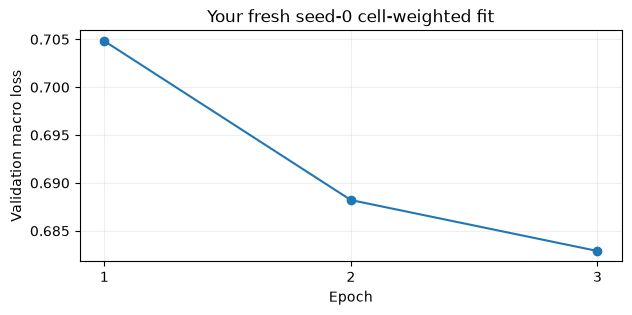

In [19]:
plt.figure(figsize=(7,3))
plt.plot([1,2,3],[e["validation"]["macro_loss"] for e in fresh["epochs"]],marker="o")
plt.xlabel("Epoch");plt.ylabel("Validation macro loss");plt.title("Your fresh seed-0 cell-weighted fit")
plt.xticks([1,2,3]);plt.grid(alpha=.2);plt.show()

## RUN · Complete six-fit course reproduction (gated)
The author-reference experiment contains all six fits. Enable this cell to rerun all six in your own runtime. It uses your live functions and the full population, and does not call a paid service. The repository command uses a 3,600-second aggregate watchdog; interactive notebook runs are your separately initiated work. Whole-paper reproduction remains NOT_RUN.

In [20]:
RUN_ALL_SIX=False
if RUN_ALL_SIX:
 full_root=Path(tempfile.mkdtemp(prefix="l173-six-fits-"))
 full_results=[train_run(arrays,tasks,arm,seed,full_root/f"{arm}-{seed}",weight_fn=task_weights,select_fn=select_epoch) for seed in [0,1,2] for arm in ["cell","task"]]
 (full_root/"report.json").write_text(json.dumps(full_results,indent=2)+"\n")
else:
 print("Six fresh notebook fits NOT_RUN; six saved author fits are a separate evidence lane.")

Six fresh notebook fits NOT_RUN; six saved author fits are a separate evidence lane.


## EXIT · Defend the objective
Write 200–400 words addressing: cell versus task weighting; numerical versus category losses; a target-copy leak; missing cross-sample architecture; and why autocomplete is not transfer. Submit code, fresh results and your defense. A completed training run alone does not pass this gate.

In [21]:
submission=dict(defense="",fresh_run_macro_loss=fresh["test"]["macro_loss"],selected_epoch=fresh["selected_epoch"],learner="PENDING_WRITTEN_DEFENSE",whole_paper_reproduction="NOT_RUN",transfer="NOT_ESTABLISHED")
Path("l173-submission.json").write_text(json.dumps(submission,indent=2)+"\n")
print("Learner PENDING_WRITTEN_DEFENSE")

Learner PENDING_WRITTEN_DEFENSE
